In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import pandas as pd
import numpy as np

In [2]:
df_data = pd.read_csv('/content/sample_data/climate_data.csv')

In [3]:
#setup variables
target = 'maintenance_frequency'
features_to_drop = ['road_id', 'timestamp', 'location_lat', 'location_lon', 'maintenance_required', 'maintenance_cost']
X = df_data.drop(columns=features_to_drop + [target], errors='ignore')
y = df_data[target]

In [4]:
#preprocessing (handling missing values)
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X.select_dtypes(include=['object']).columns

In [5]:
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X.select_dtypes(include=['object']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', SimpleImputer(strategy='mean'), numerical_cols),
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_cols)
    ])

In [6]:
#split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
#initializing and training model
model = Pipeline(steps=[('preprocessor', preprocessor),
                        ('model', LinearRegression())])
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', SimpleImputer(),
                                                  Index(['surface_temperature', 'surface_humidity', 'precipitation_rate',
       'crack_density', 'pothole_depth', 'roughness_index', 'wind_speed',
       'solar_radiation', 'vehicle_count', 'heavy_vehicle_ratio',
       'extreme_weather_event'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['terrain_type'], dtype='object'))])),
                ('model', LinearRegression())])

In [8]:
#predicting the data
y_pred = model.predict(X_test)

In [9]:
#calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

In [10]:
print("=== Model (Linear Regression) Evaluation Results ===")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

=== Model (Linear Regression) Evaluation Results ===
Mean Absolute Error (MAE): 1.2164
Root Mean Squared Error (RMSE): 1.4173
R² Score: -0.0005


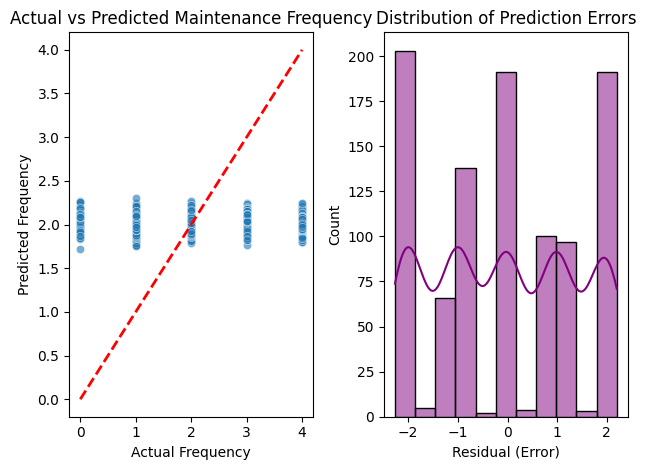


=== Top Factors Influencing Maintenance (Linear Model) ===
                      Factor  Importance
10     extreme_weather_event    0.046257
11         terrain_type_flat    0.023956
13  terrain_type_mountainous   -0.022900
2         precipitation_rate    0.007119
4              pothole_depth    0.005652


In [11]:
# Plot 1: Scattered Plot
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Frequency")
plt.ylabel("Predicted Frequency")
plt.title("Actual vs Predicted Maintenance Frequency")

# Plot 2: Residual Plot
residuals = y_test - y_pred
plt.subplot(1, 2, 2)
sns.histplot(residuals, kde=True, color='purple')
plt.xlabel("Residual (Error)")
plt.title("Distribution of Prediction Errors")

plt.tight_layout()
plt.show()

# Getting feature names back for interpretation
feature_names = list(numerical_cols) + \
    list(model.named_steps['preprocessor'].named_transformers_['cat']
         .named_steps['onehot'].get_feature_names_out(categorical_cols))

coefs = pd.DataFrame({
    'Factor': feature_names,
    'Importance': model.named_steps['model'].coef_
})
coefs['Absolute_Impact'] = coefs['Importance'].abs()
coefs = coefs.sort_values(by='Absolute_Impact', ascending=False)

print("\n=== Top Factors Influencing Maintenance (Linear Model) ===")
print(coefs[['Factor', 'Importance']].head(5))

As the model proposed in project proposal shows negative R2 means there is no linear relation between the data and maintenance
required, in graph it shows that error is a lot in predicting. now we are going to use random forest regression

In [12]:
#introducing Random Forest model
model_2 = Pipeline(steps=[('preprocessor', preprocessor),
                           ('model', RandomForestRegressor(n_estimators=100, random_state=42))])

In [13]:
#training the model
model_2.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', SimpleImputer(),
                                                  Index(['surface_temperature', 'surface_humidity', 'precipitation_rate',
       'crack_density', 'pothole_depth', 'roughness_index', 'wind_speed',
       'solar_radiation', 'vehicle_count', 'heavy_vehicle_ratio',
       'extreme_weather_event'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['terrain_type'], dtype='object'))])),
                ('model', RandomForestRegressor(random_state=42))])

In [14]:
#predicting the data
y_pred_model_2 = model_2.predict(X_test)

In [15]:
#Calculations for random forest
mae = mean_absolute_error(y_test, y_pred_model_2)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_model_2))
r2 = r2_score(y_test, y_pred_model_2)
print("=== Model 2 (Random Forest Regressor) Evaluation Metrics ===")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R2): {r2:.4f}")

=== Model 2 (Random Forest Regressor) Evaluation Metrics ===
Mean Absolute Error (MAE): 1.2365
Root Mean Squared Error (RMSE): 1.4311
R-squared (R2): -0.0200



=== Top Factors Affecting Road Maintenance (Random Forest) ===
            Feature  Importance
   surface_humidity    0.102065
 precipitation_rate    0.101037
surface_temperature    0.097660
heavy_vehicle_ratio    0.096954
      crack_density    0.096440
         wind_speed    0.095718
      vehicle_count    0.094522
    solar_radiation    0.094500
      pothole_depth    0.093728
    roughness_index    0.093398


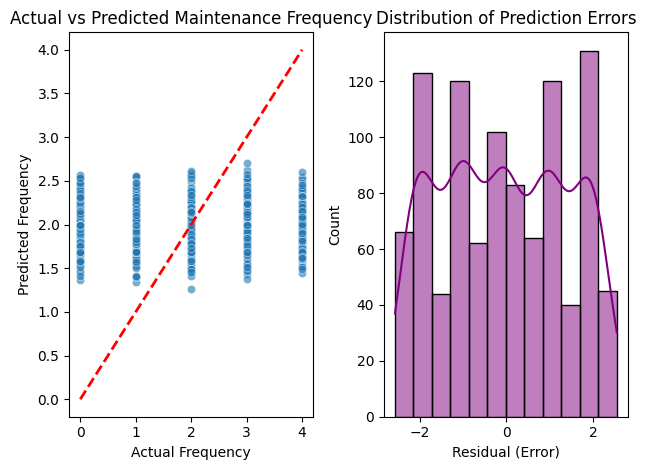

In [16]:
# Calculaing Importance score
ohe = (model_2.named_steps['preprocessor']
       .named_transformers_['cat']
       .named_steps['onehot'])
feature_names = list(numerical_cols) + list(ohe.get_feature_names_out(categorical_cols))
importances = model_2.named_steps['model'].feature_importances_
feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False)

print("\n=== Top Factors Affecting Road Maintenance (Random Forest) ===")
print(feature_imp_df.head(10).to_string(index=False))

# Plot 1: Scattered Plot
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test, y=y_pred_model_2, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Frequency")
plt.ylabel("Predicted Frequency")
plt.title("Actual vs Predicted Maintenance Frequency")

# Plot 2: Residual Plot
residuals = y_test - y_pred_model_2
plt.subplot(1, 2, 2)
sns.histplot(residuals, kde=True, color='purple')
plt.xlabel("Residual (Error)")
plt.title("Distribution of Prediction Errors")

plt.tight_layout()
plt.show()

Random forest regression also shows -ve value of R2, which means it also performed poorly ans the residual value was also high

In [17]:
from sklearn.ensemble import GradientBoostingRegressor

In [18]:
gbr_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    # Using more estimators and a slightly deeper tree for better complexity capture
    ('model', GradientBoostingRegressor(n_estimators=150, learning_rate=0.1, max_depth=4, random_state=42))
])

# 5. Train and Evaluate
gbr_model.fit(X_train, y_train)
y_pred_gbr = gbr_model.predict(X_test)

# 6. Evaluation Metrics
mae = mean_absolute_error(y_test, y_pred_gbr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_gbr))
r2 = r2_score(y_test, y_pred_gbr)

print("=====================================================")
print("Gradient Boosting Regressor Evaluation")
print("=====================================================")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R2): {r2:.4f}")

Gradient Boosting Regressor Evaluation
Mean Absolute Error (MAE): 1.2389
Root Mean Squared Error (RMSE): 1.4362
R-squared (R2): -0.0273


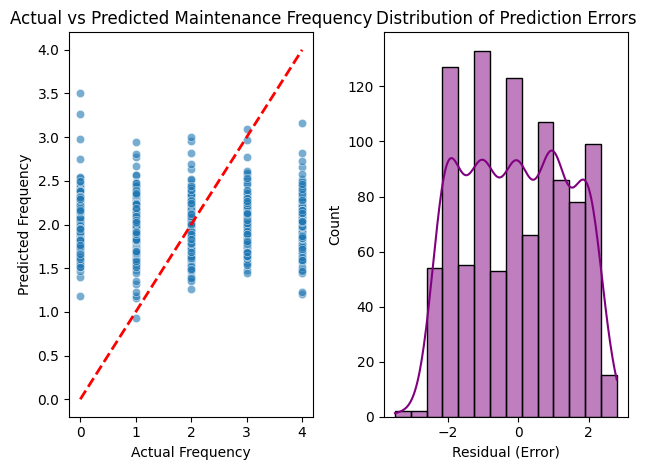

In [19]:
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test, y=y_pred_gbr, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Frequency")
plt.ylabel("Predicted Frequency")
plt.title("Actual vs Predicted Maintenance Frequency")

# Plot 2: Residuals (Errors)
residuals = y_test - y_pred_gbr
plt.subplot(1, 2, 2)
sns.histplot(residuals, kde=True, color='purple')
plt.xlabel("Residual (Error)")
plt.title("Distribution of Prediction Errors")

plt.tight_layout()
plt.show()

In [20]:
ohe = (gbr_model.named_steps['preprocessor']
       .named_transformers_['cat']
       .named_steps['onehot'])
feature_names = list(numerical_cols) + list(ohe.get_feature_names_out(categorical_cols))

# Extract importance scores from the trained model
importances = gbr_model.named_steps['model'].feature_importances_
feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
# Sort the factors by importance score
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False)

print("=====================================================")
print("Top 10 Factors Influencing Maintenance Frequency")
print("(Based on Gradient Boosting Feature Importance Score)")
print("=====================================================")
print(feature_imp_df.head(10).to_string(index=False))

Top 10 Factors Influencing Maintenance Frequency
(Based on Gradient Boosting Feature Importance Score)
            Feature  Importance
   surface_humidity    0.118263
 precipitation_rate    0.111706
surface_temperature    0.110647
heavy_vehicle_ratio    0.109782
         wind_speed    0.098698
      crack_density    0.093601
    solar_radiation    0.091955
    roughness_index    0.088240
      pothole_depth    0.085620
      vehicle_count    0.074382
